# 03 — Classical Training

Train SVM, Random Forest, and XGBoost classifiers on precomputed classical features.
This notebook loads features from data/processed/classical, builds train/val/test splits using data/splits manifests, and evaluates models with confusion matrices and ROC‑AUC.

In [8]:
# Imports
import os, json, yaml
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV
sns.set_context('talk'); sns.set_style('whitegrid')
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False


## Paths and config

In [9]:
def detect_root():
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if all((p/d).exists() for d in ['config','data','scripts','notebooks']):
            return p
    return cwd
ROOT = detect_root()
CONFIG_PATH = ROOT/'config'/'config.yaml'
SPLITS_DIR = ROOT/'data'/'splits'
CLASSICAL_DIR = ROOT/'data'/'processed'/'classical'
PLOTS_DIR = ROOT/'results'/'plots'; PLOTS_DIR.mkdir(parents=True, exist_ok=True)
EVALS_DIR = ROOT/'results'/'evaluations'; EVALS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = ROOT/'models'/'trained'/'classical'; MODELS_DIR.mkdir(parents=True, exist_ok=True)
cfg = yaml.safe_load(open(CONFIG_PATH,'r'))
classes = cfg.get('config',{}).get('classes', [])
classes

# === Extract training grids from config ===
grids = cfg.get('training', {}).get('classical', {})

# Debug: Show what grids contains
print("Available grids from config:")
print(json.dumps(grids, indent=2))



Available grids from config:
{
  "svm": {
    "kernel": [
      "rbf"
    ],
    "C": [
      0.1,
      1,
      10
    ],
    "gamma": [
      "scale",
      "auto"
    ]
  },
  "random_forest": {
    "n_estimators": [
      50,
      100,
      200
    ],
    "max_depth": [
      10,
      20,
      30,
      null
    ],
    "min_samples_split": [
      2,
      5,
      10
    ]
  },
  "xgboost": {
    "n_estimators": [
      50,
      100,
      200
    ],
    "max_depth": [
      3,
      6,
      9
    ],
    "learning_rate": [
      0.01,
      0.1,
      0.3
    ]
  }
}


## Build split indices from manifests

In [10]:
def read_manifest(path: Path):
    stems=set()
    if not path.exists(): return stems
    for line in open(path,'r'):
        line=line.strip()
        if not line: continue
        rel,label = line.split(',',1)
        stems.add(Path(rel).stem)
    return stems
split_idx = {s: read_manifest(SPLITS_DIR/f'{s}.txt') for s in ['train','val','test']}
{k: len(v) for k,v in split_idx.items()}


{'train': 979, 'val': 210, 'test': 212}

## Load classical features by split

In [11]:
def collect_features_for_split(split_stems):
    X_list, y_list, paths = [], [], []
    class_names = sorted([p.name for p in CLASSICAL_DIR.iterdir() if p.is_dir()])
    lab = {c:i for i,c in enumerate(class_names)}
    for cdir in CLASSICAL_DIR.iterdir():
        if not cdir.is_dir(): continue
        y = lab[cdir.name]
        for f in cdir.glob('*.npy'):
            base = f.stem.split('_seg')[0]
            if base in split_stems:
                arr = np.load(f)
                arr = arr.reshape(1,-1) if arr.ndim>1 else arr[np.newaxis,...]
                X_list.append(arr.astype(np.float32))
                y_list.append(y)
                paths.append(str(f))
    if not X_list:
        return np.empty((0,)), np.empty((0,),dtype=int), []
    X = np.vstack(X_list); y = np.array(y_list, dtype=int)
    return X, y, paths

X_train, y_train, _ = collect_features_for_split(split_idx['train'])
X_val,   y_val,   _ = collect_features_for_split(split_idx['val'])
X_test,  y_test,  _ = collect_features_for_split(split_idx['test'])
X_train.shape, X_val.shape, X_test.shape


((9615, 54), (1502, 54), (2119, 54))

In [16]:
# Cell 4: Compute class weights (as provided earlier)
from sklearn.utils.class_weight import compute_class_weight

classes_sorted = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes_sorted, y=y_train)
class_weight_dict = {int(k): float(v) for k, v in zip(classes_sorted, weights)}

print("Train class distribution:", np.bincount(y_train))
print("Computed class weights:", class_weight_dict)

sample_weights_train = np.array([class_weight_dict[int(y)] for y in y_train], dtype=np.float32)



Train class distribution: [2121 4846 2648]
Computed class weights: {0: 1.511079679396511, 1: 0.6613702022286422, 2: 1.2103474320241692}


## Train models (GridSearchCV)

In [17]:
# === KNN Training ===
from sklearn.neighbors import KNeighborsClassifier

print("\n=== KNN Training ===")

# Pipeline
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Grid search
knn_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# GridSearchCV
knn_cv = GridSearchCV(
    knn_pipe, knn_grid,
    cv=3, n_jobs=-1,
    scoring='f1_weighted',
    verbose=1
)
knn_cv.fit(X_train, y_train)

print("Best KNN params:", knn_cv.best_params_)
print(f"Best CV score: {knn_cv.best_score_:.4f}")



=== KNN Training ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best KNN params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best CV score: 0.9161


In [18]:
# === XGBoost Training with Sample Weights ===
if HAS_XGB:
    from xgboost import XGBClassifier
    
    print("\n=== XGBoost Training ===")
    
    # Pipeline
    xgb_pipe = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('xgb', XGBClassifier(
            objective='multi:softprob',
            num_class=len(classes),
            eval_metric='mlogloss',
            tree_method='hist',
            random_state=42
        ))
    ])
    
    # Grid from config
    xg_raw = grids.get('xgboost', {})
    xgb_grid = {
        'xgb__n_estimators': xg_raw.get('n_estimators', [50, 100, 200]),
        'xgb__max_depth': xg_raw.get('max_depth', [3, 6, 9]),
        'xgb__learning_rate': xg_raw.get('learning_rate', [0.01, 0.1, 0.3]),
    }
    
    # GridSearchCV with sample weights
    xgb_cv = GridSearchCV(
        xgb_pipe, xgb_grid,
        cv=3, n_jobs=-1,
        scoring='f1_weighted',
        verbose=1
    )
    
    # Fit with sample_weight parameter
    xgb_cv.fit(X_train, y_train, xgb__sample_weight=sample_weights_train)  # ← sample_weight here
    
    print("Best XGB params:", xgb_cv.best_params_)
    print(f"Best CV score: {xgb_cv.best_score_:.4f}")
else:
    print("XGBoost not available — skipping.")
    xgb_cv = None



=== XGBoost Training ===
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best XGB params: {'xgb__learning_rate': 0.3, 'xgb__max_depth': 6, 'xgb__n_estimators': 200}
Best CV score: 0.9329


In [19]:
# === Random Forest Training with Class Weights ===
from sklearn.ensemble import RandomForestClassifier

print("\n=== Random Forest Training ===")

# Pipeline with class-weighted RF
rf_pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # Sparse-safe scaler
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))  # ← class_weight added
])

# Grid from config
rf_grid = {
    'rf__n_estimators': grids.get('random_forest', {}).get('n_estimators', [50, 100, 200]),
    'rf__max_depth': grids.get('random_forest', {}).get('max_depth', [10, 20, None]),
    'rf__min_samples_split': grids.get('random_forest', {}).get('min_samples_split', [2, 5, 10])
}

# GridSearchCV
rf_cv = GridSearchCV(
    rf_pipe, rf_grid,
    cv=3, n_jobs=-1,
    scoring='f1_weighted',
    verbose=1
)
rf_cv.fit(X_train, y_train)

print("Best RF params:", rf_cv.best_params_)
print(f"Best CV score: {rf_cv.best_score_:.4f}")



=== Random Forest Training ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best RF params: {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV score: 0.9145


In [20]:
# === SVM Training with Class Weights ===
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("\n=== SVM Training ===")

# Pipeline with class-weighted SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, class_weight='balanced'))  # ← class_weight added
])

# Grid from config
grids = cfg.get('training', {}).get('classical', {})
svm_grid = {
    'svc__kernel': grids.get('svm', {}).get('kernel', ['rbf']),
    'svc__C': grids.get('svm', {}).get('C', [0.1, 1, 10]),
    'svc__gamma': grids.get('svm', {}).get('gamma', ['scale', 'auto'])
}

# GridSearchCV
svm_cv = GridSearchCV(
    svm_pipe, svm_grid,
    cv=3, n_jobs=-1,
    scoring='f1_weighted',
    verbose=1
)
svm_cv.fit(X_train, y_train)

print("Best SVM params:", svm_cv.best_params_)
print(f"Best CV score: {svm_cv.best_score_:.4f}")



=== SVM Training ===
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVM params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV score: 0.9332


In [21]:
svm_pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True))])
rf_pipe  = Pipeline([('scaler', StandardScaler(with_mean=False)), ('rf', RandomForestClassifier(random_state=42))])
grids = cfg.get('training',{}).get('classical',{})
svm_grid = {
    'svc__kernel': grids.get('svm',{}).get('kernel',['rbf']),
    'svc__C':      grids.get('svm',{}).get('C',[1.0]),
    'svc__gamma':  grids.get('svm',{}).get('gamma',['scale'])
}
rf_grid = {
    'rf__n_estimators':    grids.get('random_forest',{}).get('n_estimators',[100]),
    'rf__max_depth':       grids.get('random_forest',{}).get('max_depth',[None]),
    'rf__min_samples_split':grids.get('random_forest',{}).get('min_samples_split',[2])
}
svm_cv = GridSearchCV(svm_pipe, svm_grid, cv=3, n_jobs=-1, scoring='f1_weighted', verbose=1)
rf_cv  = GridSearchCV(rf_pipe,  rf_grid,  cv=3, n_jobs=-1, scoring='f1_weighted', verbose=1)
svm_cv.fit(X_train, y_train); rf_cv.fit(X_train, y_train)
svm_cv.best_params_, rf_cv.best_params_


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits


({'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'},
 {'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 200})

## Evaluate on validation

In [22]:
# === Validation Set Evaluation ===
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Collect models
models = {
    'SVM': svm_cv.best_estimator_,
    'Random Forest': rf_cv.best_estimator_,
    'KNN': knn_cv.best_estimator_,
}

if HAS_XGB and xgb_cv is not None:
    models['XGBoost'] = xgb_cv.best_estimator_

# Evaluate on validation set
results = {}

print("\n=== Validation Set Evaluation ===")
for name, model in models.items():
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    results[name] = {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_pred': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")



=== Validation Set Evaluation ===

SVM:
  Accuracy:  0.8895
  Precision: 0.8910
  Recall:    0.8895
  F1-Score:  0.8838

Random Forest:
  Accuracy:  0.9008
  Precision: 0.9078
  Recall:    0.9008
  F1-Score:  0.8947

KNN:
  Accuracy:  0.8768
  Precision: 0.8728
  Recall:    0.8768
  F1-Score:  0.8728

XGBoost:
  Accuracy:  0.9001
  Precision: 0.9038
  Recall:    0.9001
  F1-Score:  0.8956


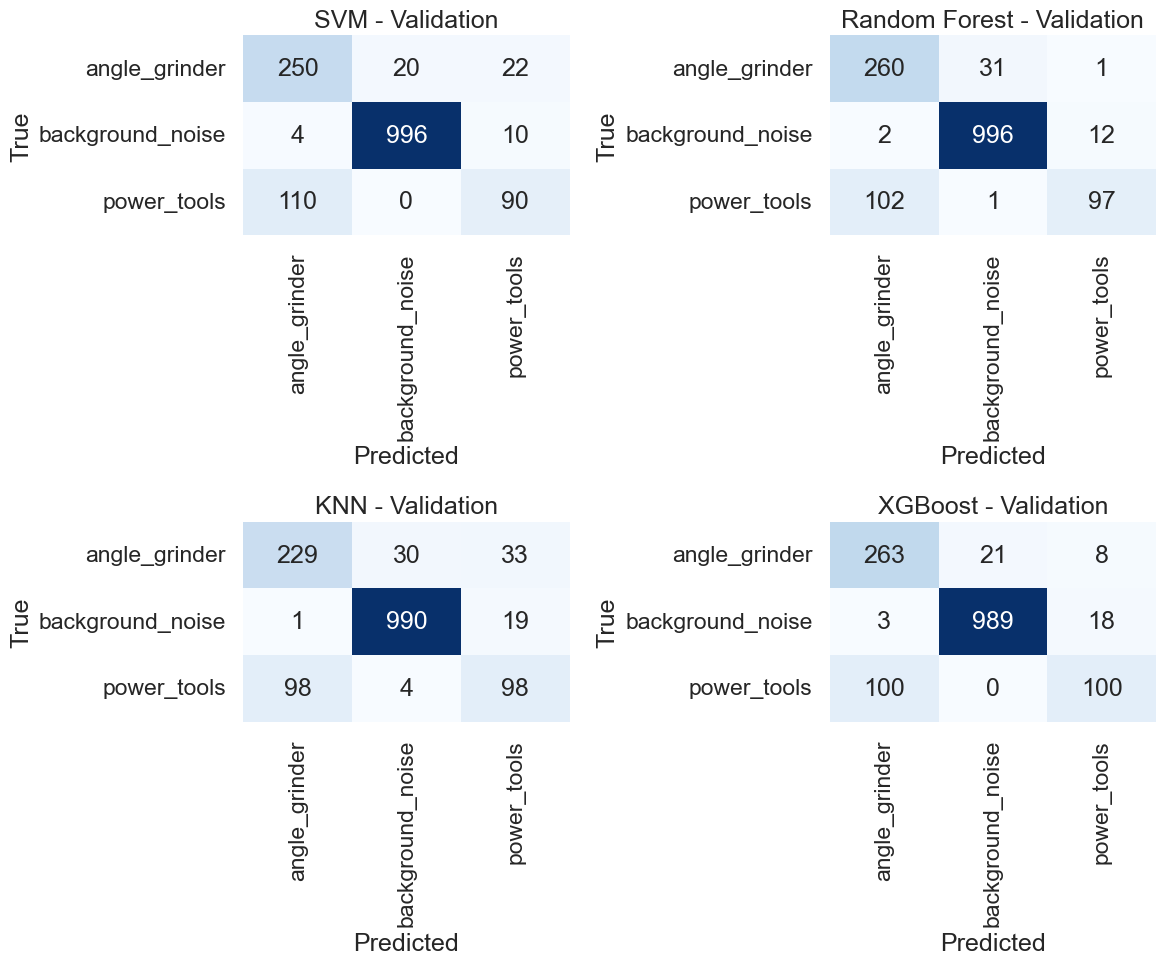

In [23]:
# === Confusion Matrices ===
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    if idx >= len(axes):
        break
    
    y_pred = res['y_pred']
    cm = confusion_matrix(y_val, y_pred, labels=list(range(len(classes))))
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes, yticklabels=classes,
        ax=axes[idx], cbar=False
    )
    axes[idx].set_title(f'{name} - Validation')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

# Hide unused subplots
for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'all_models_confusion_val.png', dpi=150)
plt.show()



SVM Validation Report
                   precision    recall  f1-score   support

   angle_grinder       0.69      0.86      0.76       292
background_noise       0.98      0.99      0.98      1010
     power_tools       0.74      0.45      0.56       200

        accuracy                           0.89      1502
       macro avg       0.80      0.76      0.77      1502
    weighted avg       0.89      0.89      0.88      1502



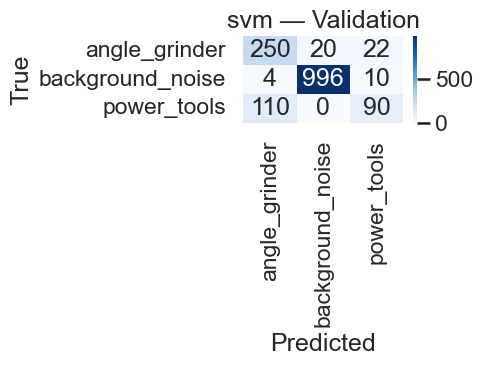


RF Validation Report
                   precision    recall  f1-score   support

   angle_grinder       0.71      0.89      0.79       292
background_noise       0.97      0.99      0.98      1010
     power_tools       0.88      0.48      0.63       200

        accuracy                           0.90      1502
       macro avg       0.85      0.79      0.80      1502
    weighted avg       0.91      0.90      0.89      1502



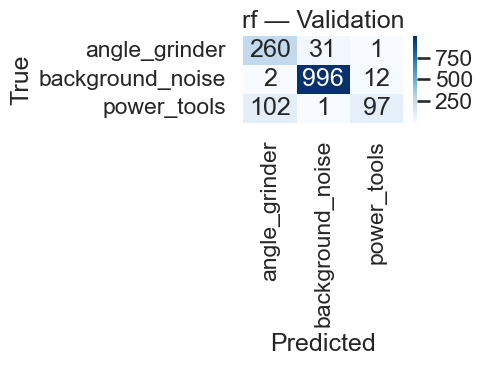

In [24]:
def plot_confusion(y_true, y_pred, class_names, title, save_path):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()

for name, est in {'svm': svm_cv.best_estimator_, 'rf': rf_cv.best_estimator_}.items():
    y_pred = est.predict(X_val)
    rep = classification_report(y_val, y_pred, target_names=classes, output_dict=False)
    print(f"\n{name.upper()} Validation Report\n", rep)
    plot_confusion(y_val, y_pred, classes, f"{name} — Validation", PLOTS_DIR / f"{name}_val_confusion_nb.png")



## XGBoost

Fitting 3 folds for each of 27 candidates, totalling 81 fits

XGB Validation Report
                   precision    recall  f1-score   support

   angle_grinder       0.71      0.90      0.79       292
background_noise       0.98      0.98      0.98      1010
     power_tools       0.84      0.49      0.62       200

        accuracy                           0.90      1502
       macro avg       0.84      0.79      0.80      1502
    weighted avg       0.91      0.90      0.90      1502



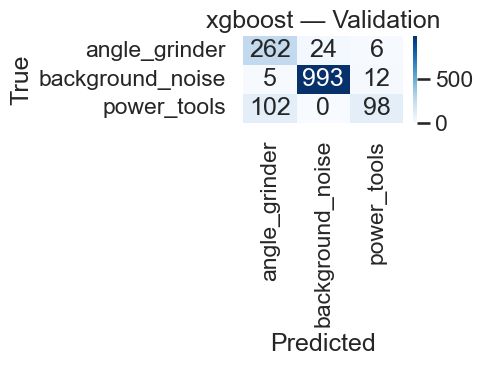

In [25]:
if HAS_XGB:
    xg_raw = grids.get('xgboost', {})
    xgb = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('xgb', XGBClassifier(
            objective='multi:softprob',
            num_class=len(classes),
            eval_metric='mlogloss',
            tree_method='hist',
            random_state=42
        ))
    ])
    xgb_grid = {
        'xgb__n_estimators': xg_raw.get('n_estimators', [100]),
        'xgb__max_depth': xg_raw.get('max_depth', [6]),
        'xgb__learning_rate': xg_raw.get('learning_rate', [0.1]),
    }
    xgb_cv = GridSearchCV(xgb, xgb_grid, cv=3, n_jobs=-1, scoring='f1_weighted', verbose=1)
    xgb_cv.fit(X_train, y_train)
    y_pred = xgb_cv.best_estimator_.predict(X_val)
    print("\nXGB Validation Report\n", classification_report(y_val, y_pred, target_names=classes, output_dict=False))
    plot_confusion(y_val, y_pred, classes, "xgboost — Validation", PLOTS_DIR / "xgboost_val_confusion_nb.png")
else:
    print("XGBoost not available — skipping.")



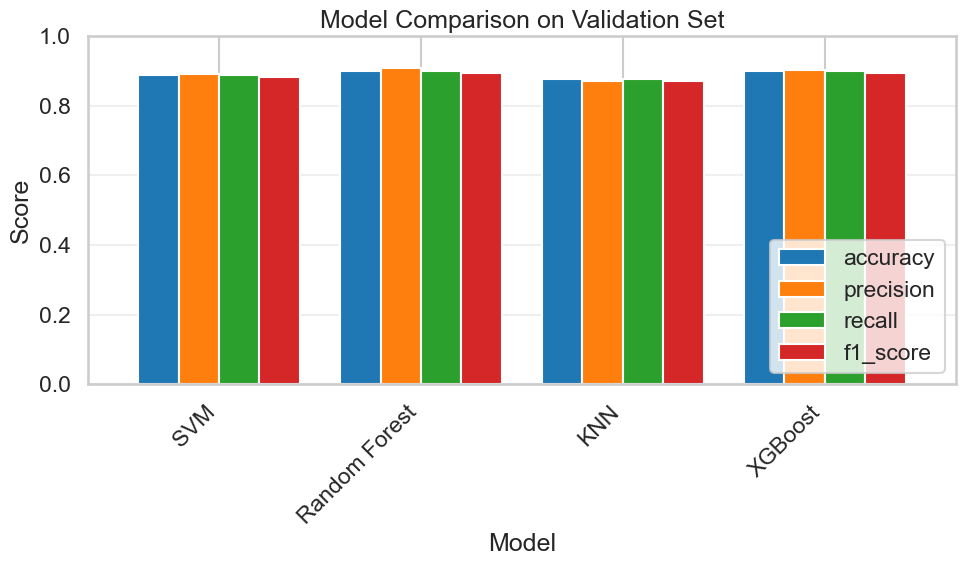


=== Summary Table ===
               accuracy precision    recall  f1_score
SVM            0.889481  0.890951  0.889481  0.883763
Random Forest  0.900799  0.907787  0.900799  0.894692
KNN            0.876831  0.872834  0.876831  0.872762
XGBoost        0.900133  0.903832  0.900133  0.895554


In [26]:
# === Model Comparison Bar Chart ===
import pandas as pd

# Create DataFrame
df_results = pd.DataFrame(results).T
df_results = df_results[['accuracy', 'precision', 'recall', 'f1_score']]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
df_results.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Comparison on Validation Set')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_comparison_bar.png', dpi=150)
plt.show()

print("\n=== Summary Table ===")
print(df_results.round(4))


In [27]:
# === Detailed Classification Reports ===
for name, res in results.items():
    y_pred = res['y_pred']
    print(f"\n{'='*60}")
    print(f"{name} - Validation Set")
    print('='*60)
    print(classification_report(y_val, y_pred, target_names=classes))



SVM - Validation Set
                  precision    recall  f1-score   support

   angle_grinder       0.69      0.86      0.76       292
background_noise       0.98      0.99      0.98      1010
     power_tools       0.74      0.45      0.56       200

        accuracy                           0.89      1502
       macro avg       0.80      0.76      0.77      1502
    weighted avg       0.89      0.89      0.88      1502


Random Forest - Validation Set
                  precision    recall  f1-score   support

   angle_grinder       0.71      0.89      0.79       292
background_noise       0.97      0.99      0.98      1010
     power_tools       0.88      0.48      0.63       200

        accuracy                           0.90      1502
       macro avg       0.85      0.79      0.80      1502
    weighted avg       0.91      0.90      0.89      1502


KNN - Validation Set
                  precision    recall  f1-score   support

   angle_grinder       0.70      0.78      0.74

In [28]:
# === Test Set Evaluation (Run Once Only) ===
print("\n=== TEST SET EVALUATION ===")
print("(Use sparingly — only for final reporting)")

test_results = {}

for name, model in models.items():
    y_pred_test = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred_test, average='weighted')
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    
    test_results[name] = {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_pred': y_pred_test
    }
    
    print(f"\n{name} (Test Set):")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Save test results
df_test = pd.DataFrame(test_results).T[['accuracy', 'precision', 'recall', 'f1_score']]
df_test.to_csv(EVALS_DIR / 'classical_test_results.csv')
print(f"\n✓ Test results saved to {EVALS_DIR / 'classical_test_results.csv'}")



=== TEST SET EVALUATION ===
(Use sparingly — only for final reporting)

SVM (Test Set):
  Accuracy:  0.7504
  Precision: 0.7971
  Recall:    0.7504
  F1-Score:  0.7128

Random Forest (Test Set):
  Accuracy:  0.7079
  Precision: 0.7640
  Recall:    0.7079
  F1-Score:  0.6394

KNN (Test Set):
  Accuracy:  0.7414
  Precision: 0.7530
  Recall:    0.7414
  F1-Score:  0.7105

XGBoost (Test Set):
  Accuracy:  0.7286
  Precision: 0.7814
  Recall:    0.7286
  F1-Score:  0.6814

✓ Test results saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv3/results/evaluations/classical_test_results.csv


AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_tight'

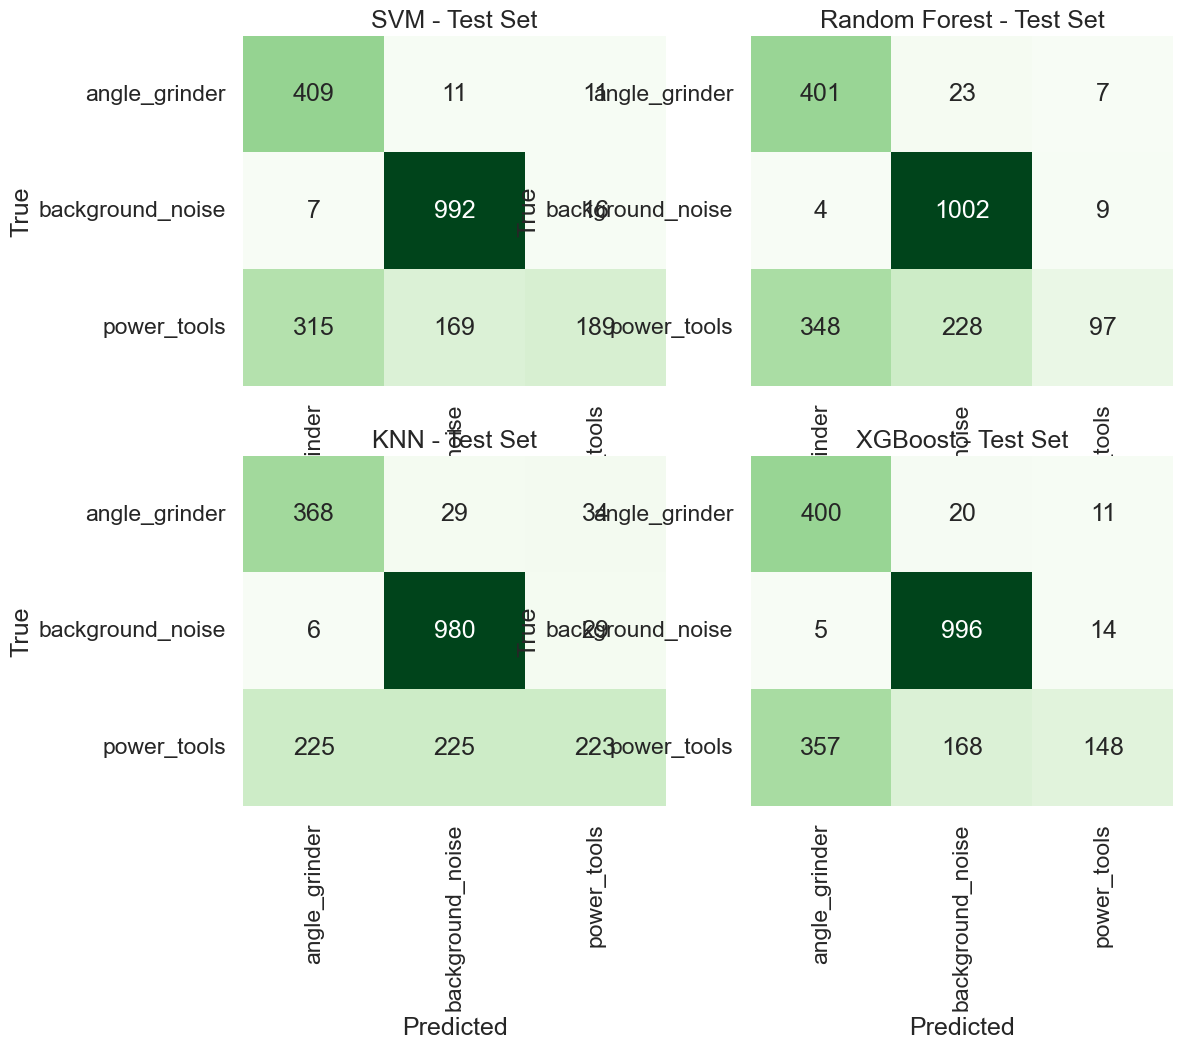

In [29]:
# === Test Set Confusion Matrices ===
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(test_results.items()):
    if idx >= len(axes):
        break
    
    y_pred_test = res['y_pred']
    cm = confusion_matrix(y_test, y_pred_test, labels=list(range(len(classes))))
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Greens',
        xticklabels=classes, yticklabels=classes,
        ax=axes[idx], cbar=False
    )
    axes[idx].set_title(f'{name} - Test Set')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

for idx in range(len(test_results), len(axes)):
    axes[idx].axis('off')

plt.tight_tight()
plt.savefig(PLOTS_DIR / 'all_models_confusion_test.png', dpi=150)
plt.show()


In [ ]:
# === Save Trained Models ===
import joblib

MODELS_SAVE_DIR = ROOT / 'models' / 'trained' / 'classical'
MODELS_SAVE_DIR.mkdir(parents=True, exist_ok=True)

for name, model in models.items():
    safe_name = name.lower().replace(' ', '_')
    save_path = MODELS_SAVE_DIR / f'{safe_name}_model.pkl'
    joblib.dump(model, save_path)
    print(f"✓ Saved {name} to {save_path}")

print(f"\n✓ All models saved to {MODELS_SAVE_DIR}")
